8B3, on refait 2B7 avec un fluide Power-Law

<img src='../images/Chap-2-Prob-2B7.png'>

In [1]:
#
# Pierre Proulx
#
# Préparation de l'affichage et des outils de calcul symbolique
#
import sympy as sp
from IPython.display import *
sp.init_printing(use_latex=True)
%matplotlib inline

In [2]:
# définitions variables, paramètres.
r,L,R,rho,g,kappa,v_0,m=sp.symbols('r,L,R,rho,g,kappa,v_0,m')
n=sp.symbols('n',positive=True)
v_z=sp.Function('v_z')(r)
tau_rz=sp.Function('tau_rz')(r)

In [3]:
eq1=r*tau_rz
eq2=-1/r*eq1.diff(r)
display(eq2)

In [4]:
eq3=sp.dsolve(eq2)
display(eq3)               

In [5]:
powerlaw=m*(-v_z.diff(r)**(n+1))
eq4=eq3.subs(tau_rz,powerlaw)             # comme 2B7 mais avec un fluide Power-Law
#eq4=eq3.subs(tau_rz,-mu*v_z.diff(r))     # substituer la loi de Newton pour le taux
display(eq4)

In [6]:
eq5=sp.Eq(-m*v_z.diff(r),eq4.rhs**(1/(n+1)))  # on simplifie la solution
display(eq5)

In [7]:
v_z=sp.dsolve(eq5)
display('profil de vitesse général, avant de trouver les constantes C1 et C2',v_z)

'profil de vitesse général, avant de trouver les constantes C1 et C2'

In [8]:
v_z=v_z.rhs
condition_1=v_z.subs(r,R)
condition_2=v_z.subs(r,kappa*R)-v_0
display('conditions aux limites',condition_1,condition_2)
C1,C2=sp.symbols('C1,C2')
constantes=sp.solve([condition_1,condition_2], sp.symbols('C1,C2'),dict=True)
constantes=constantes.pop()
C1=constantes[sp.symbols('C1')]
C2=constantes[sp.symbols('C2')]

'conditions aux limites'

In [9]:
# Valeurs numériques pour tester les profils dépendant de la rhéologie
# du fluide... Libre à vous de faire des tests.
dico={'rho':1000, 'm':0.001,'g':9.81,'kappa':0.5,'R':0.05,'v_0':1}
v_z=v_z.subs(constantes).simplify()
v_z=v_z.subs(dico).subs(n,0.8)
display('profil de vitesse après substitution des constantes C1 et C2 pour n=0.8',v_z.simplify())

'profil de vitesse après substitution des constantes C1 et C2 pour n=0.8'

In [10]:
#
# Débit volumétrique
#
debit=sp.integrate(v_z*r,(r,kappa.subs(dico)*R.subs(dico),R.subs(dico)))
display(debit.simplify())

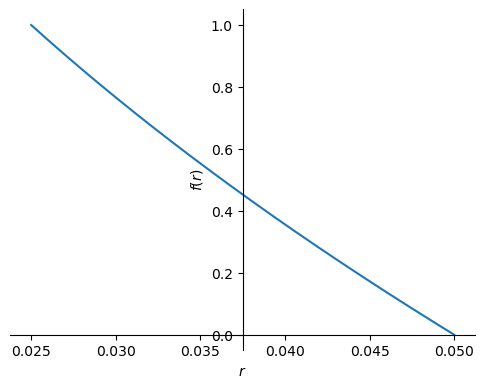

In [11]:
import matplotlib.pyplot as plt
display(v_z)
plt.rcParams['figure.figsize'] = 5,4
sp.plot(v_z,(r,kappa.subs(dico)*R.subs(dico),R.subs(dico)));